In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !pip install --upgrade certifi

In [3]:
# !pip install gtts pydub audioop-lts
# !pip install --upgrade certifi # added certifi-2025.10.5, though check https://api.msedgeservices.com
import time
import os
import pandas as pd
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont
from moviepy import ImageClip
from utils_data import (
    load_raw_data, check_dups, filter_df_to_vocab_of_interest, 
    fill_default_settings, delete_previous_attempt_files
    )
from utils_video import (
    combine_clips_with_audio_to_create_video, create_icon_from_slide,
    draw_word_index, draw_logo, draw_previous_word, draw_previous_sent,
    draw_vocab_based_on_format, generate_intro_slide,
    generate_word_list_slide, generate_outro_slide,
    fill_default_video_configs
)
from utils_audio import (
    create_tts_files_for_one_vocab_word, compute_pinyin_and_create_recordings,
    combine_audio_files_and_compute_durations,
    generate_nonvocab_audio_and_compute_durations, create_final_audio_from_each_word_and_nonvocab
)
hanzi_font_path = '/System/Library/Fonts/STHeiti Medium.ttc'
pd.options.display.max_columns = 100
pd.options.display.max_rows = 130

In [4]:
# reload configs
from configs.v052_2026feb import (
    data_settings, output_path,
    video_configs,
    nonvocab_slides, subtitle_text_configs,
    DEFAULT_TEXT_PROPERTIES,
)
if subtitle_text_configs is not None:
    subtitle_text_configs['font'] = ImageFont.truetype(subtitle_text_configs['font_name'], subtitle_text_configs['font_size'])

In [5]:
truly_load_data = True
to_delete = True

# 0. Create dataframe of settings

In [6]:
# Fill in default data settings
data_settings = fill_default_settings(data_settings)

# Fill in default video configs
video_configs = fill_default_video_configs(video_configs)

# Create folder for non-audio recordings for this project
project_artifacts_folder = f"{output_path}{data_settings['recording_name']}"
data_settings['audio_path'] = f"{project_artifacts_folder}/audio_{data_settings['filename_suffix']}.mp3"
data_settings['video_path'] = f"{project_artifacts_folder}/video_{data_settings['filename_suffix']}.mp4"

# Create folder if not exists, and delete previous files if desired
if not os.path.exists(project_artifacts_folder):
    os.mkdir(project_artifacts_folder)
if to_delete:
    delete_previous_attempt_files(project_artifacts_folder, data_settings)

# Create folders for audio tts
voice_name_keys = ['voice_name_zh', 'voice_name_en', 'voice_name_convo']
for vnk in voice_name_keys:
    if vnk in data_settings:
        if isinstance(data_settings[vnk], dict):
            for speaker, voice_name in data_settings[vnk].items():
                tts_path = f"output/tts/{voice_name}"
                if not os.path.exists(tts_path):
                    os.mkdir(tts_path)
        else:
            voice_name = data_settings[vnk]
            tts_path = f"output/tts/{voice_name}"
            if not os.path.exists(tts_path):
                os.mkdir(tts_path)

data_settings

{'recording_id': 'ce_csent',
 'silent_components': True,
 'filename_suffix': '2026feb_words',
 'types_allowed': ['word',
  'prefix',
  'suffix',
  'abbreviation',
  'multi_word',
  'verb_ending',
  'phrase',
  'speak_phrase',
  'saying',
  'idiom',
  'modal particle',
  'proper noun'],
 'max_priority': 6,
 'min_known_english_prompt': 2,
 'cat_v3_not_allowed': ['a', 'b'],
 'min_date': '2026-02-01',
 'max_date': '2026-03-01',
 'min_priority': 1,
 'max_known_english_prompt': 6,
 'min_known_pinyin_prompt': 1,
 'max_known_pinyin_prompt': 6,
 'sort_keys': ['cat_v3',
  'cat2_v3',
  'cat3_v3',
  'category1',
  'category2',
  'pinyin'],
 'sort_asc': [True, True, True, True, True, True],
 'min_combo_quality': 10,
 'categories_allowed': None,
 'categories_not_allowed': None,
 'categories2_allowed': None,
 'categories2_not_allowed': None,
 'cat_v3_allowed': None,
 'cat2_v3_allowed': None,
 'cat2_v3_not_allowed': None,
 'source1_values_allowed': None,
 'types_allowed_str': '',
 'min_adu': 3,
 'min_

# 1. Load data

In [7]:
if truly_load_data:
    df_all_vocab = load_raw_data()
    df_all_vocab.to_csv('static/latest_data.csv', index=False)
else:
    df_all_vocab = pd.read_csv('static/latest_data.csv')
    print('!!!!!!!! WARNING: not truly loading data !!!!!!!!')

df_dups = check_dups(df_all_vocab)
print(df_all_vocab.shape)
df_all_vocab.head(3)

(7706, 38)


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,1,房贷,fáng dài,mortgage,word,1.0,life,NaN,Finance & Economy,NaN,借贷与负债,MISSING,1.0,1.0,2.0,1.0,房子,house,贷款,loan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,他每个月都要还房贷,Ta měi gè yuè dōu yào huán fángdài,He has to pay his mortgage every month,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
1,2,白天,bái tiān,daytime,word,2.0,time,NaN,Time,NaN,时间段 / 时长,1.0,2.0,1.0,1.0,1.0,白,white,天,day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,白天很热晚上比较凉快,Báitiān hěn rè wǎnshàng bǐjiào liángkuai,It is hot in the daytime and cooler at night,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
2,3,组成,zǔ chéng,to form;make up,word,3.0,general,NaN,Language & Expression,NaN,逻辑与结构,MISSING,5.0,5.0,5.0,3.0,组,set,成,become,NaN,NaN,NaN,NaN,NaN,NaN,NaN,水是由氢和氧组成的,Shuǐ shì yóu qīng hé yǎng zǔchéng de,Water is made up of hydrogen and oxygen,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN


In [8]:
print(f'# duplicate vocab: {len(df_dups)}')
df_dups

# duplicate vocab: 0


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic


# 2. Select data

In [9]:
df_vocab_lists = filter_df_to_vocab_of_interest(df_all_vocab, data_settings)
n_vocab = len(df_vocab_lists)
print(data_settings['recording_name'], n_vocab)
df_vocab_lists.head(3)

0303_ce_csent_2026feb_words 104


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,7907,包裹,bāo guǒ,package,word,4.0,NaN,NaN,Business & Shopping,NaN,NaN,MISSING,5.0,5.0,5.0,6.0,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,快递员送来了一个包裹。,kuài dì yuán sòng lái le yí gè bāo guǒ.,The courier delivered a package.,2026-02-28,daily add,NaN,NaN,5.0,5.0,5.0,NaN
1,7906,菜鸟驿站,cài niǎo yì zhàn,Cainiao pickup station,proper noun,4.0,NaN,NaN,Business & Shopping,NaN,NaN,MISSING,5.0,5.0,5.0,4.0,菜鸟,newbie,驿站,relay station,NaN,NaN,NaN,NaN,NaN,NaN,菜鸟: newbie\n驿站: relay station,我的包裹到了菜鸟驿站。,wǒ de bāo guǒ dào le cài niǎo yì zhàn.,My package has arrived at the Cainiao pickup s...,2026-02-28,daily add,NaN,NaN,5.0,5.0,5.0,NaN
2,7879,平替,píng tì,replacement;cheaper alternative,word,6.0,NaN,NaN,Business & Shopping,NaN,NaN,MISSING,5.0,5.0,5.0,4.0,公平,fair,代替,replace,NaN,NaN,NaN,NaN,NaN,NaN,公平: fair\n代替: replace,这个牌子算是大牌的平替。,zhè ge pái zi suàn shì dà pái de píng tì.,This brand is considered an affordable alterna...,2026-02-28,daily add,NaN,NaN,5.0,5.0,5.0,NaN


# 3. Create vocabulary audio recordings

In [10]:
# os.remove('output/tts/zh-CN-XiaoyuMultilingualNeural/今天下雨记得带雨衣.mp3')
if data_settings['recording_id'] == '005':
    df_vocab_lists = compute_pinyin_and_create_recordings(df_vocab_lists)

start_time = time.time()
for i_row, row in df_vocab_lists.iterrows():
    print(f"{(time.time()-start_time):.1f}s, row{i_row}")
    create_tts_files_for_one_vocab_word(row, data_settings)

0.0s, row0
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 包裹
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, package
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 快递员送来了一个包裹。
0.0s, row1
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 菜鸟驿站
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, Cainiao pickup station
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 我的包裹到了菜鸟驿站。
0.0s, row2
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 平替
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, replacement;cheaper alternative
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 这个牌子算是大牌的平替。
0.0s, row3
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 跑腿
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, run errands
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 我请他帮我跑腿买咖啡。
0.0s, row4
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 钉鞋
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, spiked shoes;cleats
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 运动员穿着钉鞋参加比赛。
0.0s, row5
0.000s, ALREADY EXISTS, zh-CN-Xiaox

## 3b. Compute durations of combined audios for each vocab word

In [11]:
# os.remove('output/tts/zh-CN-XiaoxiaoNeural/蛇是典型的爬行动物。.mp3')

In [12]:
audio_duration_file_name = f"{project_artifacts_folder}/audio_durations_vocab_only.csv"
if os.path.exists(audio_duration_file_name):
    df_vocab_audio_durations = pd.read_csv(audio_duration_file_name)
    print(f"Loaded existing audio durations for {data_settings['recording_name']}, shape {df_vocab_audio_durations.shape}")
else:
    df_vocab_audio_durations = combine_audio_files_and_compute_durations(df_vocab_lists, data_settings)
    df_vocab_audio_durations.to_csv(audio_duration_file_name, index=False)

df_vocab_audio_durations['nonvocab_file_path'] = None
df_vocab_audio_durations['nonvocab_pause_ms'] = None
df_vocab_audio_durations['nonvocab_key'] = None
print(f"Total duration: {df_vocab_audio_durations['combined'].sum()}s")
df_vocab_audio_durations.head(3)

0.39 seconds, recid0303_ce_csent_2026feb_words, row 0, 包裹
0.31 seconds, recid0303_ce_csent_2026feb_words, row 1, 菜鸟驿站
0.29 seconds, recid0303_ce_csent_2026feb_words, row 2, 平替
0.29 seconds, recid0303_ce_csent_2026feb_words, row 3, 跑腿
0.29 seconds, recid0303_ce_csent_2026feb_words, row 4, 钉鞋
0.30 seconds, recid0303_ce_csent_2026feb_words, row 5, 挡风被
0.30 seconds, recid0303_ce_csent_2026feb_words, row 6, 蝴蝶结
0.32 seconds, recid0303_ce_csent_2026feb_words, row 7, 家居服
0.30 seconds, recid0303_ce_csent_2026feb_words, row 8, 头盔
0.30 seconds, recid0303_ce_csent_2026feb_words, row 9, 房奴
0.30 seconds, recid0303_ce_csent_2026feb_words, row 10, 很俗
0.31 seconds, recid0303_ce_csent_2026feb_words, row 11, 喇叭
0.30 seconds, recid0303_ce_csent_2026feb_words, row 12, 考古
0.29 seconds, recid0303_ce_csent_2026feb_words, row 13, 填空
0.29 seconds, recid0303_ce_csent_2026feb_words, row 14, 怀旧
0.30 seconds, recid0303_ce_csent_2026feb_words, row 15, 另有所图
0.29 seconds, recid0303_ce_csent_2026feb_words, row 16, 灵感


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key
0,包裹,bāo guǒ,package,快递员送来了一个包裹。,kuài dì yuán sòng lái le yí gè bāo guǒ.,The courier delivered a package.,5.0,NaN,1.200,1.056,2.424,0.2,1.900,3.456,6.680,6.679583,,None,None,None
1,菜鸟驿站,cài niǎo yì zhàn,Cainiao pickup station,我的包裹到了菜鸟驿站。,wǒ de bāo guǒ dào le cài niǎo yì zhàn.,My package has arrived at the Cainiao pickup s...,5.0,NaN,1.632,2.040,2.400,0.2,2.332,4.872,8.072,8.071583,菜鸟: newbie\n驿站: relay station,None,None,None
2,平替,píng tì,replacement;cheaper alternative,这个牌子算是大牌的平替。,zhè ge pái zi suàn shì dà pái de píng tì.,This brand is considered an affordable alterna...,5.0,NaN,1.296,3.000,2.928,0.2,1.996,5.496,9.224,9.223583,公平: fair\n代替: replace,None,None,None


# 4. Create non-vocab audio recordings

In [13]:
df_vocab_audio_durations, audio_filler_variables, nonvocab_slides = generate_nonvocab_audio_and_compute_durations(
    data_settings, df_vocab_audio_durations, nonvocab_slides, project_artifacts_folder)
df_vocab_audio_durations.head()

intro audio already generated: 我的普通话数据库视频 52
outro audio already generated: 如果你有任何问题、建议或反馈，请留言。请点赞并订阅。


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_english,start_sent
0,我的普通话数据库视频 52,wǒ de pǔtōnghuà shùjùkù shìpín 52,My Mandarin Chinese Database Video 52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.720000,NaN,output/videos/0303_ce_csent_2026feb_words/我的普通...,500,intro,3.720000,0.000000,NaN,NaN,NaN
1,包裹,bāo guǒ,package,快递员送来了一个包裹。,kuài dì yuán sòng lái le yí gè bāo guǒ.,The courier delivered a package.,5.0,NaN,1.200,1.056,2.424,0.2,1.900,3.456,6.680,6.679583,,None,None,None,10.399583,3.720000,3.920000,5.620000,7.176000
2,菜鸟驿站,cài niǎo yì zhàn,Cainiao pickup station,我的包裹到了菜鸟驿站。,wǒ de bāo guǒ dào le cài niǎo yì zhàn.,My package has arrived at the Cainiao pickup s...,5.0,NaN,1.632,2.040,2.400,0.2,2.332,4.872,8.072,8.071583,菜鸟: newbie\n驿站: relay station,None,None,None,18.471167,10.399583,10.599583,12.731583,15.271583
3,平替,píng tì,replacement;cheaper alternative,这个牌子算是大牌的平替。,zhè ge pái zi suàn shì dà pái de píng tì.,This brand is considered an affordable alterna...,5.0,NaN,1.296,3.000,2.928,0.2,1.996,5.496,9.224,9.223583,公平: fair\n代替: replace,None,None,None,27.694750,18.471167,18.671167,20.467167,23.967167
4,跑腿,pǎo tuǐ,run errands,我请他帮我跑腿买咖啡。,wǒ qǐng tā bāng wǒ pǎo tuǐ mǎi kā fēi.,I asked him to run an errand and buy coffee fo...,5.0,NaN,1.272,1.344,2.712,0.2,1.972,3.816,7.328,7.327583,跑: run\n腿: leg,None,None,None,35.022333,27.694750,27.894750,29.666750,31.510750


# 5. Combine individual vocab into final audio recording

In [14]:
if not os.path.exists(data_settings['audio_path']):
    create_final_audio_from_each_word_and_nonvocab(df_vocab_audio_durations, data_settings)
else:
    print(f"Final audio already exists at {data_settings['audio_path']}")

10.02s, output/videos/0303_ce_csent_2026feb_words/audio_2026feb_words.mp3


# 6. Create images for video

In [15]:
# If don't want to rerun the above cells, then just run this cell to load the audio durations
audio_generation_previous_run = True
if audio_generation_previous_run:
    try:
        df_vocab_audio_durations = pd.read_csv(f"{project_artifacts_folder}/audio_durations_all.csv")
        print(f"{data_settings['recording_name']} loaded")
    except FileNotFoundError:
        print(f"File not found for recording {data_settings['recording_name']}, please run the cell above to generate audio durations.")
df_vocab_audio_durations.head()

0303_ce_csent_2026feb_words loaded


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_english,start_sent
0,我的普通话数据库视频 52,wǒ de pǔtōnghuà shùjùkù shìpín 52,My Mandarin Chinese Database Video 52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.720000,NaN,output/videos/0303_ce_csent_2026feb_words/我的普通...,500.0,intro,3.720000,0.000000,NaN,NaN,NaN
1,包裹,bāo guǒ,package,快递员送来了一个包裹。,kuài dì yuán sòng lái le yí gè bāo guǒ.,The courier delivered a package.,5.0,NaN,1.200,1.056,2.424,0.2,1.900,3.456,6.680,6.679583,NaN,NaN,NaN,NaN,10.399583,3.720000,3.920000,5.620000,7.176000
2,菜鸟驿站,cài niǎo yì zhàn,Cainiao pickup station,我的包裹到了菜鸟驿站。,wǒ de bāo guǒ dào le cài niǎo yì zhàn.,My package has arrived at the Cainiao pickup s...,5.0,NaN,1.632,2.040,2.400,0.2,2.332,4.872,8.072,8.071583,菜鸟: newbie\n驿站: relay station,NaN,NaN,NaN,18.471167,10.399583,10.599583,12.731583,15.271583
3,平替,píng tì,replacement;cheaper alternative,这个牌子算是大牌的平替。,zhè ge pái zi suàn shì dà pái de píng tì.,This brand is considered an affordable alterna...,5.0,NaN,1.296,3.000,2.928,0.2,1.996,5.496,9.224,9.223583,公平: fair\n代替: replace,NaN,NaN,NaN,27.694750,18.471167,18.671167,20.467167,23.967167
4,跑腿,pǎo tuǐ,run errands,我请他帮我跑腿买咖啡。,wǒ qǐng tā bāng wǒ pǎo tuǐ mǎi kā fēi.,I asked him to run an errand and buy coffee fo...,5.0,NaN,1.272,1.344,2.712,0.2,1.972,3.816,7.328,7.327583,跑: run\n腿: leg,NaN,NaN,NaN,35.022333,27.694750,27.894750,29.666750,31.510750


## 6a. Vocab words

Drawing 0: 包裹
Drawing 1: 菜鸟驿站
Drawing 2: 平替
Drawing 3: 跑腿
Drawing 4: 钉鞋
Drawing 5: 挡风被
Drawing 6: 蝴蝶结
Drawing 7: 家居服
Drawing 8: 头盔
Drawing 9: 房奴
Drawing 10: 很俗
Drawing 11: 喇叭
Drawing 12: 考古
Drawing 13: 填空
Drawing 14: 怀旧
Drawing 15: 另有所图
Drawing 16: 灵感
Drawing 17: 魅力
Drawing 18: 黏人
Drawing 19: 腻腻歪歪
Drawing 20: 情书
Drawing 21: 死缠烂打
Drawing 22: 偷感
Drawing 23: 吸引
Drawing 24: 虚惊
Drawing 25: 虚惊一场
Drawing 26: 严肃
Drawing 27: 访谈
Drawing 28: 标普500
Drawing 29: 标准普尔500指数
Drawing 30: 财经
Drawing 31: 大笔财富
Drawing 32: 大盘
Drawing 33: 高风险高回报
Drawing 34: 华尔街
Drawing 35: 降息
Drawing 36: 交易所交易基金
Drawing 37: 流动性
Drawing 38: 泡沫
Drawing 39: 泡沫塑料
Drawing 40: 赎回
Drawing 41: 首付
Drawing 42: 债券
Drawing 43: 2009年大衰退
Drawing 44: 蚝油
Drawing 45: 迷迭香
Drawing 46: 松果
Drawing 47: 馅
Drawing 48: 肋骨
Drawing 49: 肉眼
Drawing 50: 水土不服
Drawing 51: 肘部
Drawing 52: 致命
Drawing 53: 安眠药
Drawing 54: 床头柜
Drawing 55: 豪宅
Drawing 56: 停电
Drawing 57: 权力夫妇
Drawing 58: 半途而废
Drawing 59: 吃灰
Drawing 60: 此地无银三百两
Drawing 61: 大惊小怪
Drawing 62: 非要
Drawin


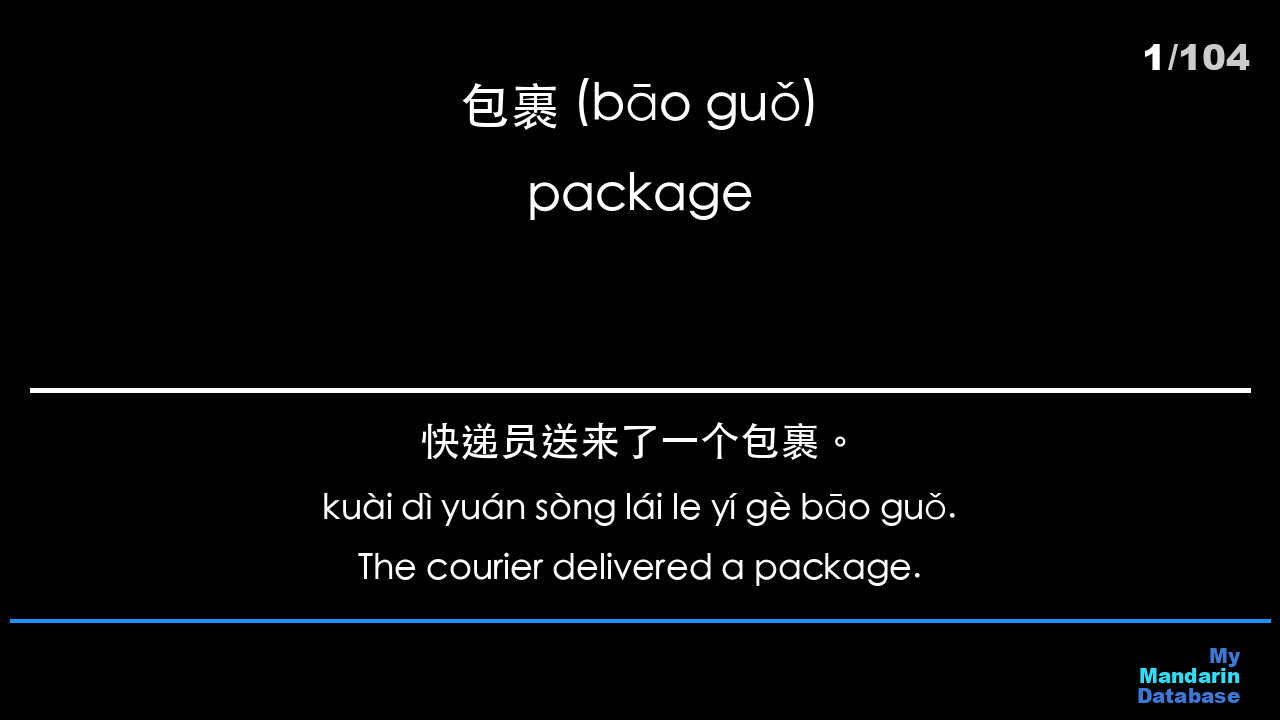

In [16]:
# Overall initializations
clips = []
previous_word = ''
previous_sent = ''

# Create folder to hold slide images
slides_path = f"{project_artifacts_folder}/slides"
if not os.path.exists(slides_path):
    os.mkdir(slides_path)

# Fill in defaults for any missing properties
for config_key, default_config_value in DEFAULT_TEXT_PROPERTIES.items():
    for vocab_slide_id, vocab_slide_settings in video_configs['vocab_slide'].items():
        if config_key not in vocab_slide_settings.keys():
            video_configs['vocab_slide'][vocab_slide_id][config_key] = default_config_value

# Iterate through each word
df_audio_durations_words_only = df_vocab_audio_durations.dropna(subset='sum_theory').reset_index(drop=True)
for word_idx, row in df_audio_durations_words_only.iterrows():
    # if row['chinese'] == '包裹':
    # Initialize image
    print(f'Drawing {word_idx}: {row["chinese"]}')
    current_image_file_path = f"{slides_path}/{row['chinese']}"
    img = Image.new("RGB", video_configs['bg_size'], color=video_configs['bg_color'])
    draw = ImageDraw.Draw(img)
    
    # Header/Footer texts
    draw_word_index(draw, video_configs, n_vocab, word_idx)
    if 'logo' in video_configs.keys():
        draw_logo(draw, video_configs)
    if 'previous_word' in video_configs.keys():
        draw_previous_word(draw, video_configs, previous_word)
    if 'previous_sent' in video_configs.keys():
        draw_previous_sent(draw, video_configs, previous_sent)
    draw.line([
        (video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y']),
        (video_configs['bg_size'][0] - video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y'])],
        fill=video_configs['footer_line']['color'],
        width=video_configs['footer_line']['width'],
        joint=None)
    
    # Update previous
    previous_word = f"{row['chinese']}\n{row['pinyin']}\n{row['english']}"
    if 'previous_sent' in video_configs.keys():
        previous_sent = f"{row['sentence']}\n{row['sentence_pinyin']}\n{row['sentence_english']}"

    # Draw vocab depending on recording ID
    # break
    draw_vocab_based_on_format(data_settings['recording_id'], row, video_configs, current_image_file_path, img, draw, clips)
    # break

my_img = clips[2]
my_img.display_in_notebook()

In [17]:
row

chinese                                                            五险一金
pinyin                                                   wǔ xiǎn yì jīn
english                     five social insurances and one housing fund
sentence                                                    这家公司提供五险一金。
sentence_pinyin                 zhè jiā gōng sī tí gōng wǔ xiǎn yì jīn.
sentence_english      This company provides five insurances and one ...
slang                                                               5.0
phonetic                                                            NaN
d_chinese                                                         1.536
d_english                                                         3.312
d_sent                                                            2.784
rel_start_chinese                                                   0.2
rel_start_english                                                 2.236
rel_start_sent                                                  

# 7. Create non-vocab slides


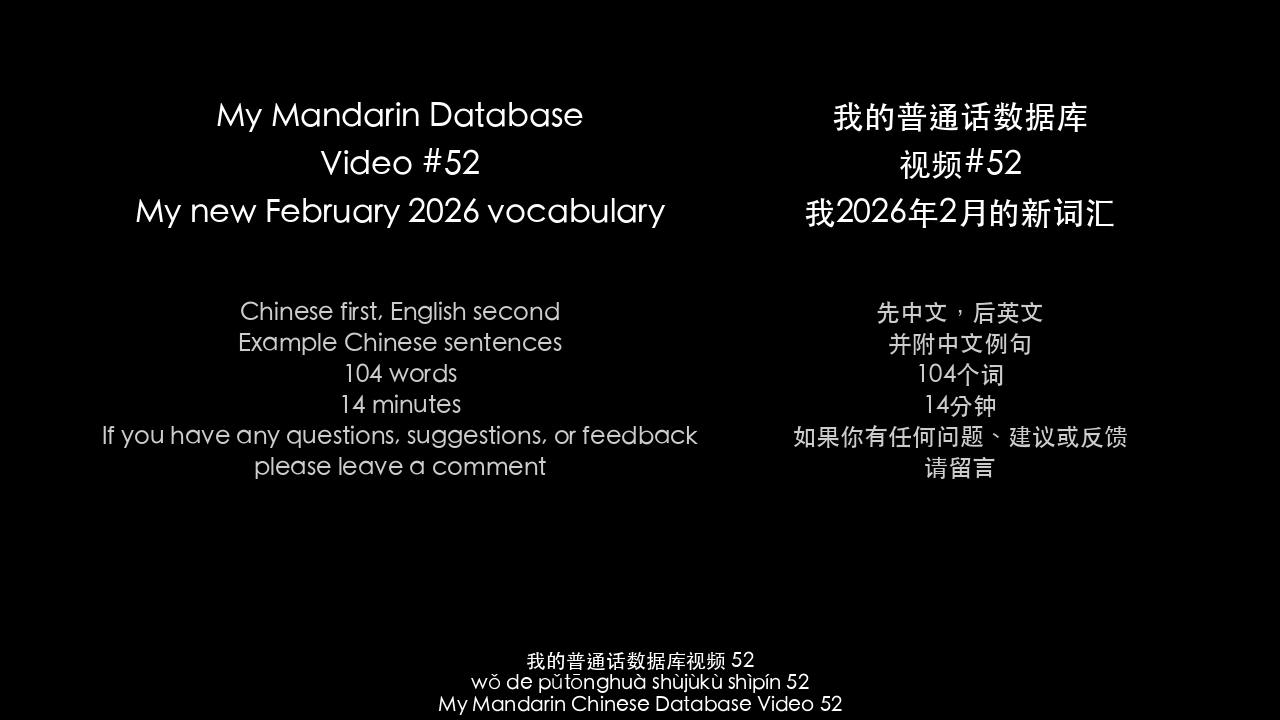

In [18]:
if nonvocab_slides is not None:
    if 'intro' in nonvocab_slides.keys():
        img = generate_intro_slide(video_configs, nonvocab_slides['intro'], subtitle_text_configs, audio_filler_variables)
        img.save(f"{project_artifacts_folder}/intro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/intro.png", duration=1).with_start(0)
my_img.display_in_notebook()


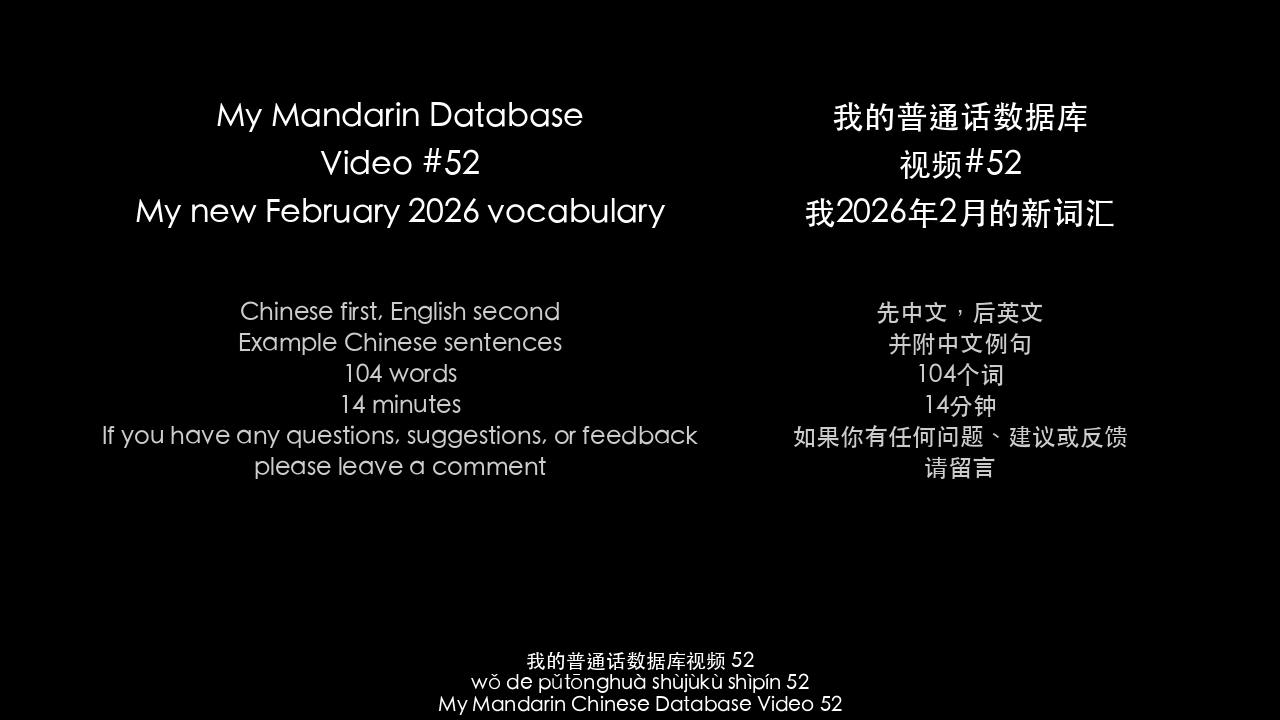

In [19]:
if nonvocab_slides is not None:
    if 'word_list' in nonvocab_slides.keys():
        img = generate_word_list_slide(video_configs, nonvocab_slides['word_list'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/word_list.png")
        my_img = ImageClip(f"{project_artifacts_folder}/word_list.png", duration=1).with_start(0)
my_img.display_in_notebook()

In [20]:
# nonvocab_slides['outro'] = {
#         'chinese': '如果你有任何问题、建议或反馈，请留言。请点赞并订阅。',
#         'pinyin': 'Rúguǒ nǐ yǒu rènhé wèntí, jiànyì huò fǎnkuì, qǐng liúyán. Qǐng diǎn zàn bìng dìngyuè.',
#         'english': 'If you have any questions, suggestions, or feedback, please leave a comment. Please like and subscribe.',
#         'clip_index': -1,
#         'change_index': None,
#         'pause_ms': 500,

#         'y_top': 10,
#         'y_bottom': 70,
#         'x_top': 10,
#         'spacing': 0,
#         'font_size': 18,
#         'fill': '#FFFFFF',
#         'align': 'left',
#         'col_space': 0,
#         'col_space_big': 0,
#         'definition_configs':{
#             'chinese': {'x_offset': 0, 'x_max': 90, 'font_path': hanzi_font_path},
#             'pinyin': {'x_offset': None, 'x_max': 165, 'font_path': hanzi_font_path},
#             'english': {'x_offset': None, 'x_max': 165, 'font_path': hanzi_font_path},
#         }
# }

reduced font size to 17
reduced font size to 16
reduced font size to 15
reduced font size to 17
reduced font size to 16
reduced font size to 15
reduced font size to 14
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 17
reduced font size to 17
reduced font size to 16
reduced font size to 15
reduced font size to 14
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 17
reduced font size to 16
reduced font size to 17
reduced font size to 16
reduced font size to 15
reduced font size to 14
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 17
reduced font size to 16
reduced font size to 15
reduced font size to 17
reduced font size to 16
reduced font size to 15
reduced font size to 14
reduced font size to 17
reduced font size to 16
reduced font size to 15
reduced font size to 14
reduced font siz


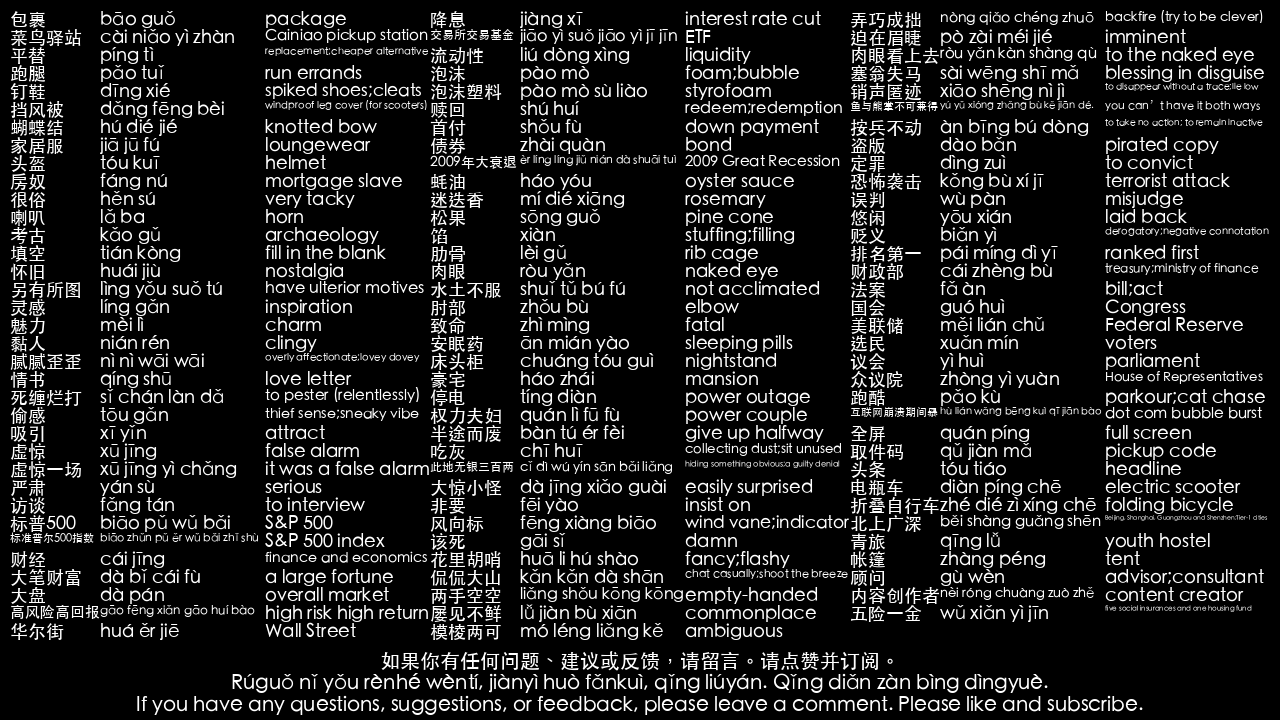

In [21]:
if nonvocab_slides is not None:
    if 'outro' in nonvocab_slides.keys():
        img = generate_outro_slide(video_configs, nonvocab_slides['outro'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/outro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/outro.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 8. Create video icon


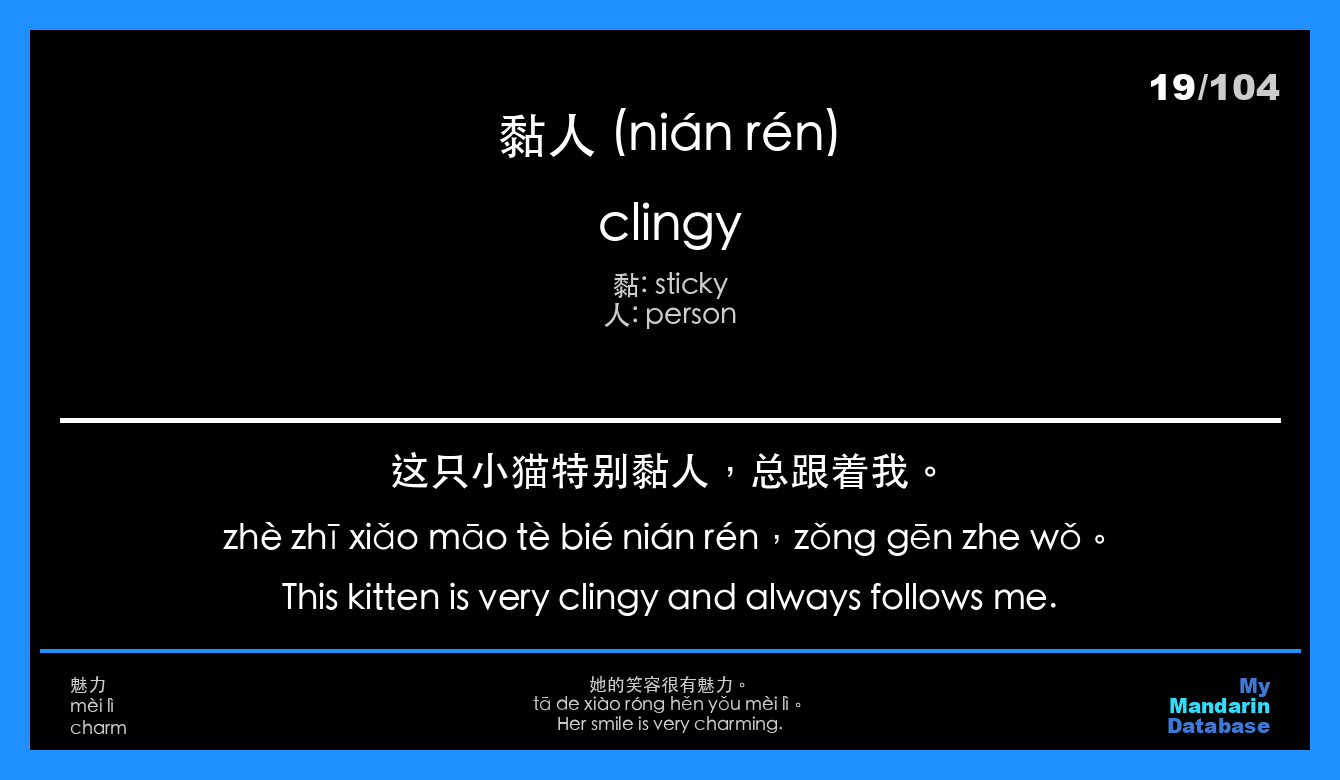

In [22]:
if 'icon_configs' in video_configs.keys():
    img = create_icon_from_slide(video_configs['icon_configs'], video_configs, project_artifacts_folder)
    img.save(f'{project_artifacts_folder}/icon.png')
    my_img = ImageClip(f"{project_artifacts_folder}/icon.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 9. Create video

In [23]:
combine_clips_with_audio_to_create_video(clips, nonvocab_slides, project_artifacts_folder, data_settings)

intro
outro
Number of clips: 314
audio: 822.360s, video: 822.305s; difference: 0.055s
MoviePy - Building video output/videos/0303_ce_csent_2026feb_words/video_2026feb_words.mp4.
MoviePy - Writing audio in video_2026feb_wordsTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
MoviePy - Writing video output/videos/0303_ce_csent_2026feb_words/video_2026feb_words.mp4



MoviePy - Done !
MoviePy - video ready output/videos/0303_ce_csent_2026feb_words/video_2026feb_words.mp4
